# Requirements

In [ ]:
from google.colab import drive, userdata
drive.mount('/content/drive', force_remount=True)
DATA_PATH = userdata.get('TBA_DATA_PATH')
EXPORT_DATE = '2026-04-20'

Mounted at /content/drive


In [ ]:
%%capture
!pip install imbalanced-learn

# Load datas

## Data exploration

In [ ]:
# ML effectifs
import pandas as pd
# EXPORT_DATE = '2026-03-30'
ml_path = DATA_PATH + f'{EXPORT_DATE}_ml_effectifs_tba.csv'
ml_df = pd.read_csv(ml_path, low_memory=False)

organisations_tba = pd.read_csv(DATA_PATH + f'{EXPORT_DATE}_organisations_tba.csv')
ml_tba = organisations_tba[organisations_tba['type']=='MISSION_LOCALE']

ml_df = ml_df.merge(ml_tba[['_id', 'nom']], left_on='mission_locale_id', right_on='_id')
print(f'- ml_df {EXPORT_DATE}: {ml_df.shape}')

- ml_df 2026-04-20: (156849, 211)


In [ ]:
ml_df['probleme_type'].value_counts()

,count
probleme_type,
jeune_injoignable,2349
autre,430
coordonnees_incorrectes,66


In [ ]:
ml_df['situation'].value_counts()

,count
situation,
CONTACTE_SANS_RETOUR,4499
NOUVEAU_PROJET,3855
DEJA_ACCOMPAGNE,2823
AUTRE,2595
RDV_PRIS,2376
INJOIGNABLE_APRES_RELANCES,2190
NOUVEAU_CONTRAT,1345
COORDONNEES_INCORRECT,933
NE_SOUHAITE_PAS_ETRE_RECONTACTE,367


In [ ]:
# Filter situations
filter = ml_df['situation'].isna()
ml_started = ml_df[~filter].copy()
ml_unstarted = ml_df[filter].copy()
print(f'- ml_started: {len(ml_started)}')
print(f'- ml_unstarted: {len(ml_unstarted)}')

#interest = ['DEJA_ACCOMPAGNE', 'RDV_PRIS']
#no_interest = [col for col in ml_df['situation'].unique() if col not in interest]
interest = ['RDV_PRIS', 'DEJA_ACCOMPAGNE', 'CHERCHE_CONTRAT', 'NOUVEAU_CONTRAT']
no_interest = [col for col in ml_df['situation'].unique() if col not in interest]
filter = ml_started['situation'].isin(interest + no_interest)
ml_started = ml_started[filter]
ml_started['label'] = ml_started['situation'].apply(lambda x: 1 if x in interest else 0)
ml_started['label'].value_counts()

- ml_started: 21044
- ml_unstarted: 135805


,count
label,
0,14494
1,6550


# Extract features

In [ ]:
# Cast as dict
import ast
import tqdm
tqdm.tqdm.pandas()

# Casting effectifs
ml_started['effectif_snapshot'] = ml_started['effectif_snapshot'].progress_apply(ast.literal_eval)

100%|██████████| 21044/21044 [00:08<00:00, 2435.56it/s]


In [ ]:
ml_started

,nom,effectif_snapshot,situation,situation_autre,probleme_type,deja_connu,updated_at,label
0,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT","{'_id': '66d3a8da21a02da5b7769d22', 'apprenant...",NOUVEAU_PROJET,NaN,NaN,False,2025-05-02T10:17:05.757+02:00,0
1,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT","{'_id': '66d3a8dc21a02da5b7769dd2', 'apprenant...",AUTRE,déjà accompagné ML,NaN,True,2025-05-02T10:18:25.378+02:00,0
2,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT","{'_id': '66d64be477205f03d086e78a', 'apprenant...",CONTACTE_SANS_RETOUR,NaN,jeune_injoignable,NaN,2025-09-24T10:07:23.182+02:00,0
4,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT","{'_id': '66e1eda36f1dbf65b64f684e', 'apprenant...",AUTRE,déjà accompagné ML,NaN,True,2025-05-02T10:25:26.547+02:00,0
5,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT","{'_id': '66fc4cc05437f6e17c8dc664', 'apprenant...",CONTACTE_SANS_RETOUR,NaN,NaN,True,2025-08-06T12:17:58.18+02:00,0
...,...,...,...,...,...,...,...,...
156211,LILLE AVENIRS,"{'deca_raw_id': '69221ebce3533d01c6fa2af4', 'a...",NOUVEAU_PROJET,NaN,NaN,NaN,2026-04-19T20:42:52.679+02:00,0
156225,DES VILLES DU NORD DU BOIS,"{'deca_raw_id': '698b95d65aaba272abf33207', 'a...",NE_SOUHAITE_PAS_ETRE_RECONTACTE,NaN,jeune_injoignable,NaN,2026-04-19T20:47:07.852+02:00,0
156765,DE MAISONS ALFORT-CHARENTON-ST MAURICE-ST MAUR,"{'deca_raw_id': '69bf00882c641a7f1861c566', 'a...",CONTACTE_SANS_RETOUR,NaN,NaN,False,2026-04-19T22:45:53.889+02:00,0
156767,DU PLATEAU DE BRIE,"{'deca_raw_id': '693f1f183bf267c44594583f', 'a...",NOUVEAU_CONTRAT,NaN,NaN,False,2026-04-20T10:09:04.604+02:00,1


In [ ]:
dataset = ml_started.copy()
dataset.rename(columns={'nom':'mission_locale'}, inplace=True)
effectifs = ml_started['effectif_snapshot'].apply(pd.Series)
apprenants = effectifs['apprenant'].apply(pd.Series).add_prefix('apprenant.')
contrats = effectifs['contrats'].apply(lambda x: pd.Series(x[0])).add_prefix('contrat.')
formations = effectifs['formation'].apply(pd.Series).add_prefix('formation.')
effectifs = pd.concat([dataset, apprenants, formations, contrats], axis=1)
#effectifs['telephone'] = effectifs['apprenant.telephone'].apply(lambda x: 1 if x else 0)
#effectifs['courriel'] = effectifs['apprenant.courriel'].apply(lambda x: 1 if x else 0)

date_cols = ['apprenant.date_de_naissance',
             'formation.date_inscription',
             'formation.date_fin',
             'formation.date_entree',
             'contrat.date_debut',
             'contrat.date_fin',
             'contrat.date_rupture',
             'updated_at'
]

features = effectifs[date_cols]

# Compute delay
features = features.map(lambda x: pd.to_datetime(str(x), utc=True, errors='coerce')) # Cast as date
features = features.sub(features['contrat.date_rupture'], axis=0) # Diff with end date
features = features.map(lambda x: x.days if isinstance(x, pd.Timedelta) else 0) # Keep days

# Extract labels
labels = dataset['label']
labels = labels.map(lambda x: 'Oui' if x else 'Non')

cat_cols = ['apprenant.sexe', 'mission_locale', 'deja_connu',
            'formation.cfd', 'formation.rncp', 'formation.niveau'
            ]
features[cat_cols] = effectifs[cat_cols].fillna('').astype(str)
features.drop(['contrat.date_rupture'], axis=1, inplace=True)

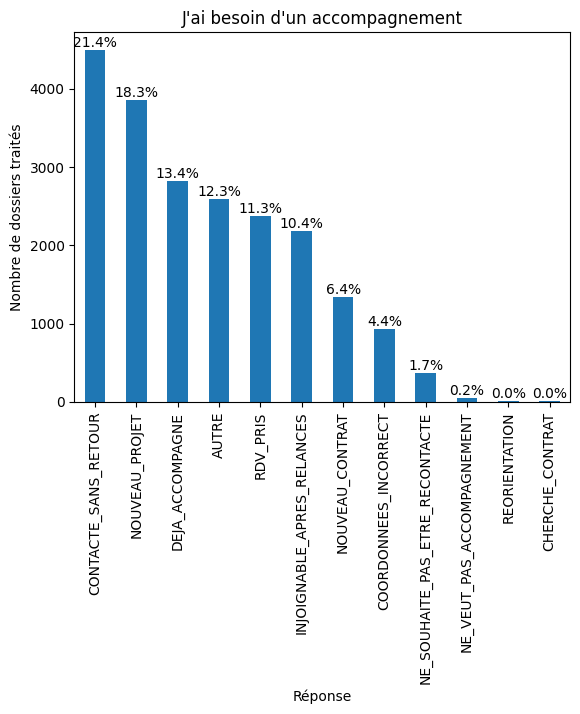

In [ ]:
import matplotlib.pyplot as plt

# Calculate value counts and proportions
value_counts = ml_started['situation'].value_counts()
proportions = ml_started['situation'].value_counts(normalize=True) * 100

# Plot label distribution
ax = value_counts.plot(kind='bar')

# Add proportion % labels on each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 0.1, # Adjust vertical position
            '{:1.1f}%'.format(proportions.iloc[i]),
            ha='center', va='bottom')

plt.title("J'ai besoin d'un accompagnement")
plt.xlabel("Réponse")
plt.ylabel("Nombre de dossiers traités")
plt.show()

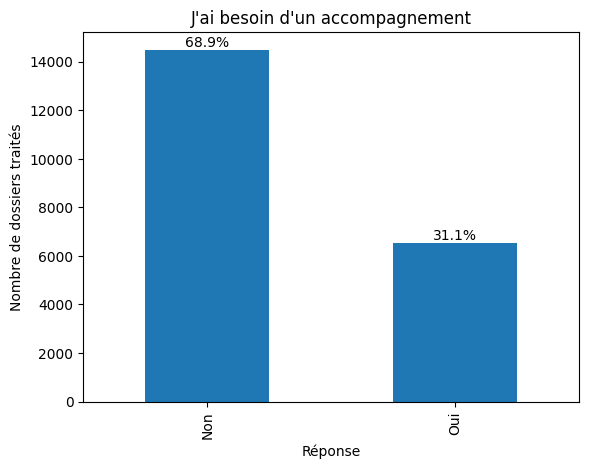

In [ ]:
import matplotlib.pyplot as plt

# Calculate value counts and proportions
value_counts = labels.value_counts()
proportions = labels.value_counts(normalize=True) * 100

# Plot label distribution
ax = value_counts.plot(kind='bar')

# Add proportion % labels on each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 0.1, # Adjust vertical position
            '{:1.1f}%'.format(proportions.iloc[i]),
            ha='center', va='bottom')

plt.title("J'ai besoin d'un accompagnement")
plt.xlabel("Réponse")
plt.ylabel("Nombre de dossiers traités")
plt.show()

In [ ]:
# Export dataset
dataset = pd.concat([features, labels], axis=1)
dataset.to_csv(DATA_PATH + f'{EXPORT_DATE} ML accompagnement dataset.csv', index=False)
dataset

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,updated_at,apprenant.sexe,mission_locale,deja_connu,formation.cfd,formation.rncp,formation.niveau,label
0,-6716,-424,244,-400,-343,306,186,F,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",False,50031224,RNCP34947,3,Non
1,-6795,-36,266,-36,-84,328,207,F,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",True,50022139,RNCP38430,3,Non
2,-5879,-104,563,-96,-162,567,285,F,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",,50031224,RNCP34947,3,Non
4,-8352,-368,289,-368,-368,350,230,F,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",True,32031212,RNCP34030,5,Non
5,-7216,-150,126,-137,-150,184,159,M,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",True,50022139,RNCP38430,3,Non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156211,-6818,-217,462,-217,-153,511,12,M,LILLE AVENIRS,,35533103,RNCP35719,5,Non
156225,-6752,-197,92,-197,-57,153,19,M,DES VILLES DU NORD DU BOIS,,50022141,RNCP38765,3,Non
156765,-7093,-58,306,-58,-17,306,17,F,DE MAISONS ALFORT-CHARENTON-ST MAURICE-ST MAUR,False,46T31202,RNCP37717,4,Non
156767,-7442,-197,899,-197,-211,899,20,M,DU PLATEAU DE BRIE,False,36T33402,RNCP35527,6,Oui


# Visualization

In [ ]:
# Reload dataset
import pandas as pd
dataset = pd.read_csv(DATA_PATH + f'{EXPORT_DATE} ML accompagnement dataset.csv').fillna('')
labels = dataset['label']
features = dataset.drop('label', axis=1)

In [ ]:
%%capture
!pip install pacmap

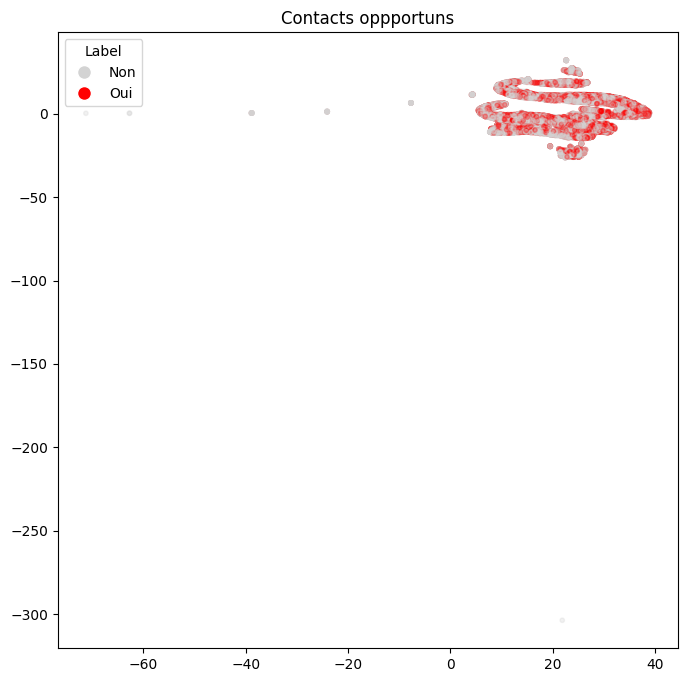

In [ ]:
# PaCMAP dimension reduction
import pacmap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get unique labels
unique_labels = sorted(list(set(labels)))

# Create a color map for unique labels
colors_list = {
    'Non':"lightgray",
    'Oui':"red"
}

# Map labels to colors
mapped_colors = [colors_list[label] for label in labels]

# Filter out non-numeric columns from features for PaCMAP
# These columns were added as strings and cause the ValueError
# features_for_pacmap = features.drop(['apprenant.sexe', 'mission_locale'], axis=1)

# Transform categorical features
features_for_pacmap = pd.get_dummies(features)

# initializing the pacmap instance
# Setting n_neighbors to "None" leads to an automatic choice shown below in "parameter" section
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0)

# fit the data (The index of transformed data corresponds to the index of the original data)
X_transformed = embedding.fit_transform(features_for_pacmap, init="pca")

# visualize the embedding
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], c=mapped_colors, s=10, alpha=0.3)

# Create a legend
plt.title("Contacts oppportuns")

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                              markerfacecolor=colors_list[label], markersize=10)
                   for label in unique_labels]
ax.legend(handles=legend_elements, title="Label")

plt.show()

# Model training

## Pipeline

In [ ]:
# Reload dataset
import pandas as pd
dataset = pd.read_csv(DATA_PATH + f'{EXPORT_DATE} ML accompagnement dataset.csv')
dataset['deja_connu'] = dataset['deja_connu'].fillna(0).apply(int)
print(f"Loaded dataset: {dataset.shape}")
labels = dataset['label']
features = dataset.drop(['label', 'mission_locale', 'formation.rncp', 'formation.cfd'], axis=1)
# features = features.drop([col for col in features.columns if 'date' in col], axis=1)

Loaded dataset: (21044, 14)


In [ ]:
features

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,updated_at,apprenant.sexe,deja_connu,formation.niveau
0,-6716,-424,244,-400,-343,306,186,F,0,3.0
1,-6795,-36,266,-36,-84,328,207,F,1,3.0
2,-5879,-104,563,-96,-162,567,285,F,0,3.0
3,-8352,-368,289,-368,-368,350,230,F,1,5.0
4,-7216,-150,126,-137,-150,184,159,M,1,3.0
...,...,...,...,...,...,...,...,...,...,...
21039,-6818,-217,462,-217,-153,511,12,M,0,5.0
21040,-6752,-197,92,-197,-57,153,19,M,0,3.0
21041,-7093,-58,306,-58,-17,306,17,F,0,4.0
21042,-7442,-197,899,-197,-211,899,20,M,0,6.0


In [ ]:
features['formation.date_realise'] = abs(features['formation.date_entree']/(features['formation.date_fin'] - features['formation.date_entree']))
features['contrat.date_realise'] = abs(features['contrat.date_debut']/(features['contrat.date_fin'] - features['contrat.date_debut']))
# Replace infinite values with NaN
features.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
# Prepare train/test dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from tqdm import tqdm
tqdm.pandas()

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42, shuffle=True, stratify=labels)

# Create training pipeline
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Define the balancing step
smote = SMOTE(random_state=42, sampling_strategy='minority')

# Identify numeric and categorical features
# Ensure X_train is a DataFrame, even if it's currently a Series
numeric_features = [col for col in X_train.columns if 'date' in col] + ['formation.niveau']
categorical_features = [col for col in X_train.columns if col not in numeric_features]
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Pipeline configuration
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    # ('pca', PCA(n_components=0.99))  # Retain 99% of variance
    ])

# Categorical pipeline: impute and encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    verbose_feature_names_out=False)

# Training pipeline with balancing
def train_model(model, X_train, y_train, X_test, y_test):
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('model', model)
        ])

    # Train and evaluate balanced KNN
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"{model.__class__.__name__} Classification Report:")
    print(classification_report(y_test, y_pred))
    return pipeline

# Cross validation score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
def cross_validation(pipeline, X, y):
    # Define a custom scorer for the minority class (assuming class 1 is minority)
    def f1_minority(y_true, y_pred):
        return f1_score(y_true, y_pred, pos_label='Oui')
    f1_scorer = make_scorer(f1_minority)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="f1_weighted")
    print(f"{pipeline.named_steps.model.__class__.__name__} CV: f1-score=%0.4f | std=%0.4f" % (scores.mean(), scores.std()))

# Confusion matrix plot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(X_test, y_test, pipeline, threshold=0.5):
    # Predict on test
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    y_test = y_test.map({'Non': 0, 'Oui': 1})

    # Apply threshold
    y_pred = (y_probs >= threshold).astype(int)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Normalize by row (true class proportion)
    # cm_normalized = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]*100
    # Normalize by column (true class proportion)
    cm_normalized = cm.astype('float') / cm.sum(axis=0)*100

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=['Non', 'Oui']
    )
    disp.plot(include_values=False, cmap='Blues', ax=ax, colorbar=False)

    # Add percentage labels
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            color = 'white' if cm_normalized[i, j] > 50 else 'black'
            ax.text(j, i, f"{cm_normalized[i, j]:.0f}%\n({cm[i,j]})", ha='center', va='center', color=color)
    ax.set_title(f"{pipeline.named_steps.model.__class__.__name__} (threshold={threshold})")
    plt.show()

# Feature importance
import builtins

def feature_importance(pipeline):
    # Get feature names after preprocessing
    feature_names_after_preprocessing = pipeline.named_steps['preprocessor'].get_feature_names_out()

    # Get importance based on model type
    model = pipeline['model']
    if isinstance(model, RandomForestClassifier) or hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        title_suffix = "(feature importances)"
    elif hasattr(model, 'coef_'):
        # For binary classification, coef_ is usually 2D, take the first row
        importance = model.coef_[0]
        title_suffix = "(coefficients)"
    else:
        print("Model type does not support feature importance extraction.")
        return

    # Create a DataFrame for visualization
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names_after_preprocessing,
        'Importance': importance
    }).sort_values('Importance', key=abs, ascending=True)

    plt.figure(figsize=(6, 6))
    nb_feat = builtins.min(20, len(importance))
    plt.barh(feature_importance_df[-nb_feat:]['Feature'], feature_importance_df[-nb_feat:]['Importance'])
    plt.title(f"Demande de RDV - {model.__class__.__name__} {title_suffix} (best {nb_feat} features)")
    plt.xlabel("Importance Value")
    plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_threshold_curve(X_test, y_test, pipeline):
    # Predict on test
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    y_test = y_test.map({'Non': 0, 'Oui': 1})

    # Définir une gamme de seuils
    thresholds = np.linspace(0.1, 0.9, 100)
    td_values = []
    fd_values = []

    for threshold in thresholds:
        # Apply threshold
        y_pred = (y_probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        td = 0 if tp+fp == 0 else tp / (tp + fp)
        td_values.append(td)
        fd = 0 if tn+fn == 0 else tn / (tn + fn)
        fd_values.append(fd)

    # Tracer le graphique
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, td_values, label='Taux de détection "oui"', color="blue")
    plt.plot(thresholds, fd_values, label='Taux de détection "non"', color="Red")
    plt.xlabel('Seuil de probabilité')
    plt.ylabel('Taux de détection')
    plt.title('Taux de détection des contacts utiles')
    plt.grid(True)
    plt.legend()
    plt.show()

preprocessor

Numeric features: ['apprenant.date_de_naissance', 'formation.date_inscription', 'formation.date_fin', 'formation.date_entree', 'contrat.date_debut', 'contrat.date_fin', 'updated_at', 'formation.date_realise', 'contrat.date_realise', 'formation.niveau']
Categorical features: ['apprenant.sexe', 'deja_connu']


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['apprenant.date_de_naissance',
                                  'formation.date_inscription',
                                  'formation.date_fin', 'formation.date_entree',
                                  'contrat.date_debut', 'contrat.date_fin',
                                  'updated_at', 'formation.date_realise',
                                  'contrat.date_realise', 'formation.niveau']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['apprenant.sexe', 'deja_connu'])],
                  verbose_feature_names_out=False)

## Dummy (32%/69%)

DummyClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.69      0.51      0.59      2899
         Oui       0.32      0.51      0.39      1310

    accuracy                           0.51      4209
   macro avg       0.51      0.51      0.49      4209
weighted avg       0.58      0.51      0.53      4209

DummyClassifier CV: f1-score=0.5201 | std=0.0088


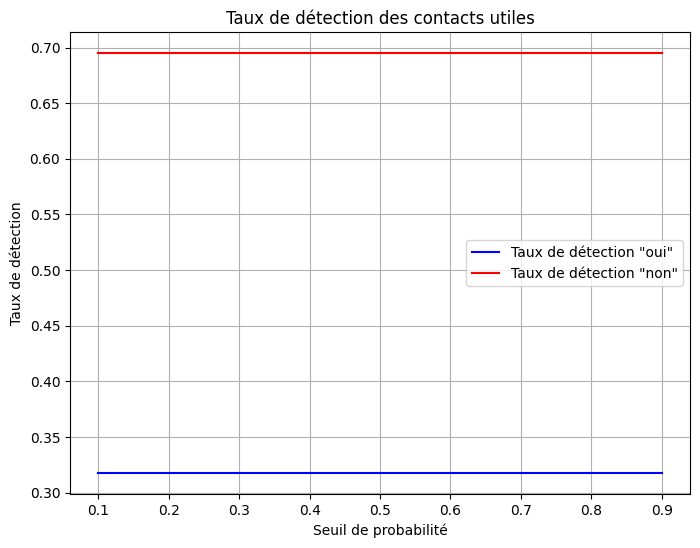

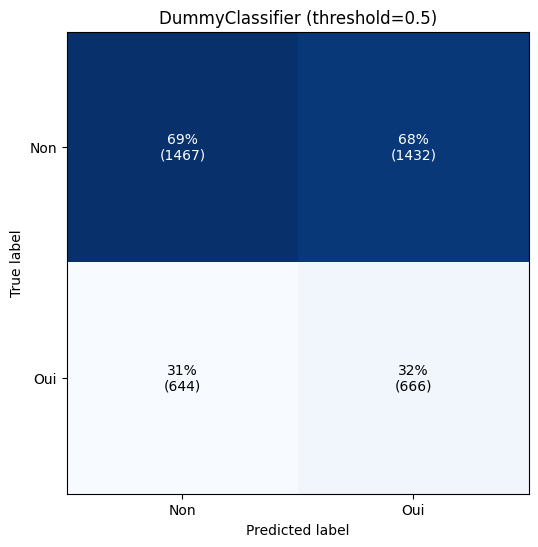

In [ ]:
# Dummy classifier
from sklearn.dummy import DummyClassifier
pipeline = train_model(DummyClassifier(strategy='stratified', random_state=42), X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)
plot_confusion_matrix(X_test, y_test, pipeline)

## KNN (48% / 81%)

KNeighborsClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.81      0.68      0.74      2899
         Oui       0.48      0.64      0.55      1310

    accuracy                           0.67      4209
   macro avg       0.64      0.66      0.64      4209
weighted avg       0.71      0.67      0.68      4209

KNeighborsClassifier CV: f1-score=0.6762 | std=0.0030


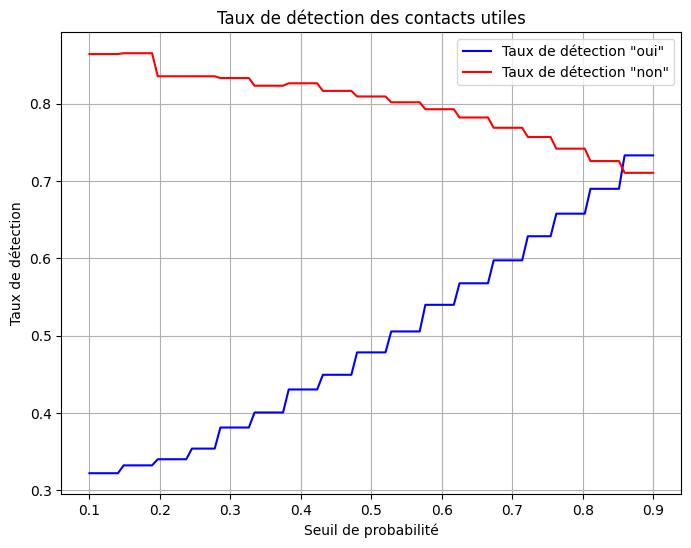

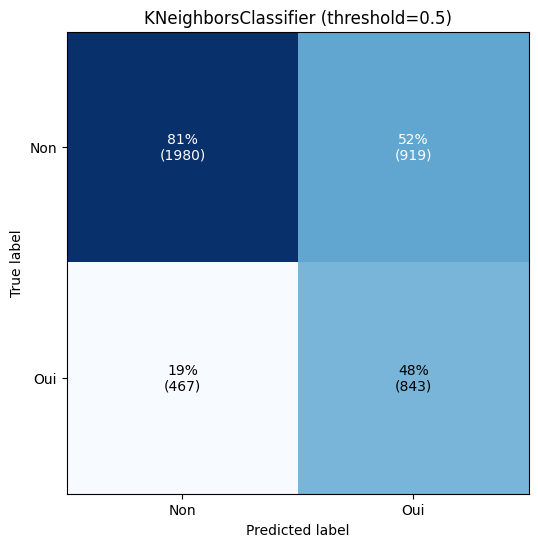

In [ ]:
# KNN classifier
from sklearn.neighbors import KNeighborsClassifier
pipeline = train_model(KNeighborsClassifier(n_neighbors=21), X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)
plot_confusion_matrix(X_test, y_test, pipeline)

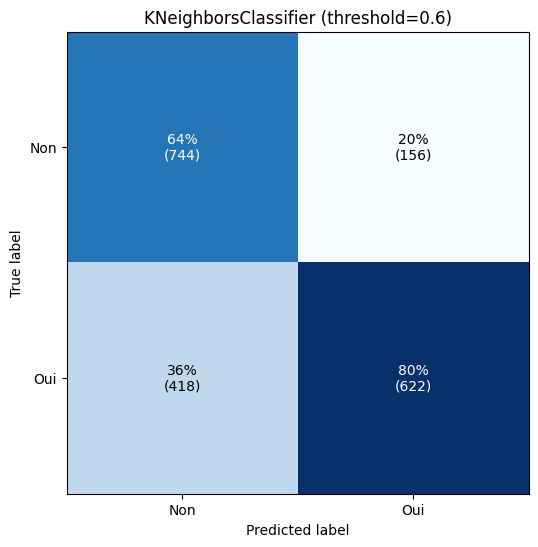

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.6)

## Logistic regression (60% / 80%)

LogisticRegression Classification Report:
              precision    recall  f1-score   support

         Non       0.80      0.84      0.82      2899
         Oui       0.60      0.52      0.56      1310

    accuracy                           0.74      4209
   macro avg       0.70      0.68      0.69      4209
weighted avg       0.74      0.74      0.74      4209

LogisticRegression CV: f1-score=0.7301 | std=0.0039


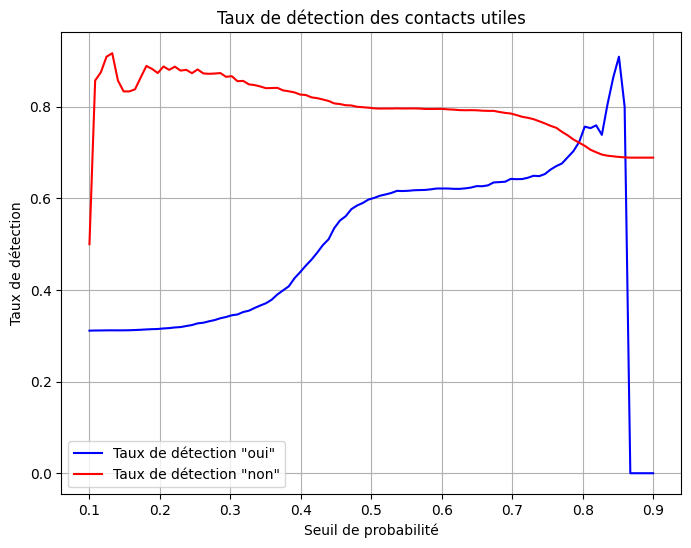

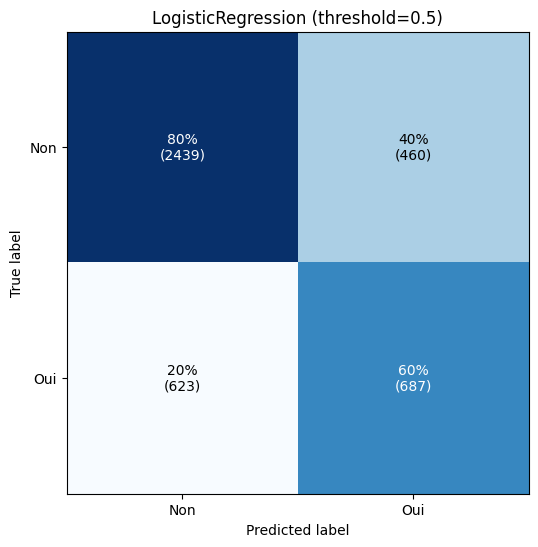

In [ ]:
# Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42, max_iter=1000, penalty='l2', solver='liblinear')
pipeline = train_model(model, X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)
plot_confusion_matrix(X_test, y_test, pipeline)

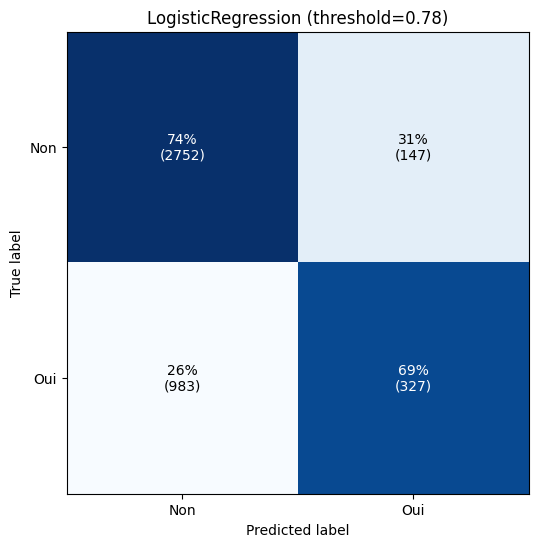

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.78)

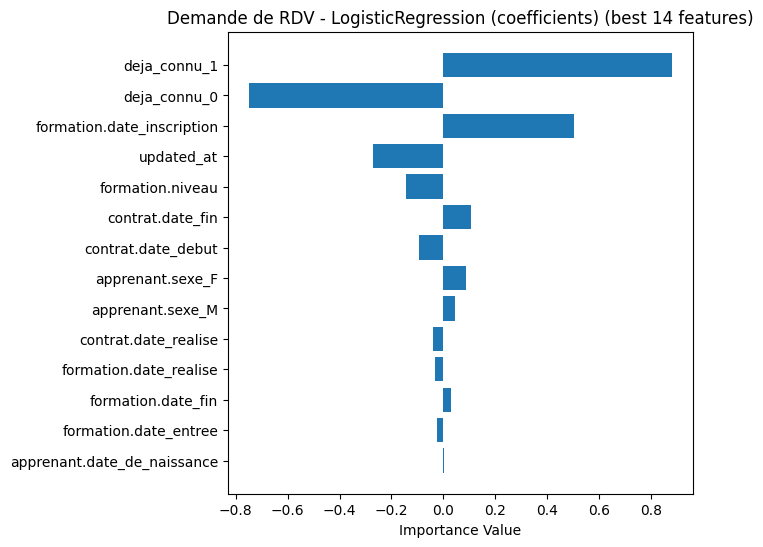

In [ ]:
feature_importance(pipeline)

## Random Forest (62% / 80%)

RandomForestClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.80      0.84      0.82      2899
         Oui       0.60      0.54      0.57      1310

    accuracy                           0.75      4209
   macro avg       0.70      0.69      0.69      4209
weighted avg       0.74      0.75      0.74      4209

RandomForestClassifier CV: f1-score=0.7324 | std=0.0042


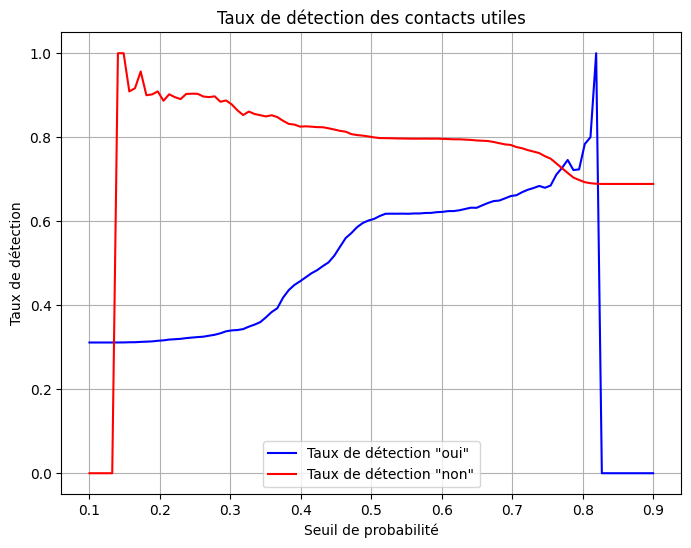

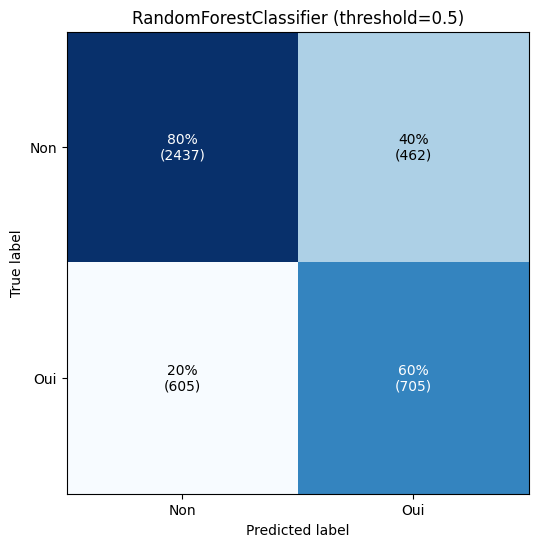

In [ ]:
# Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced', random_state=42,
                               min_samples_split=20, min_samples_leaf=2,
                               max_depth=5, max_features='sqrt',
                               n_estimators=200)
pipeline = train_model(model, X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)
plot_confusion_matrix(X_test, y_test, pipeline)

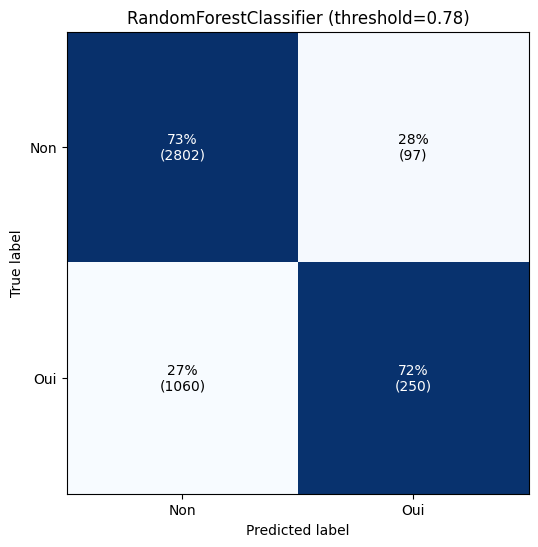

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.78)

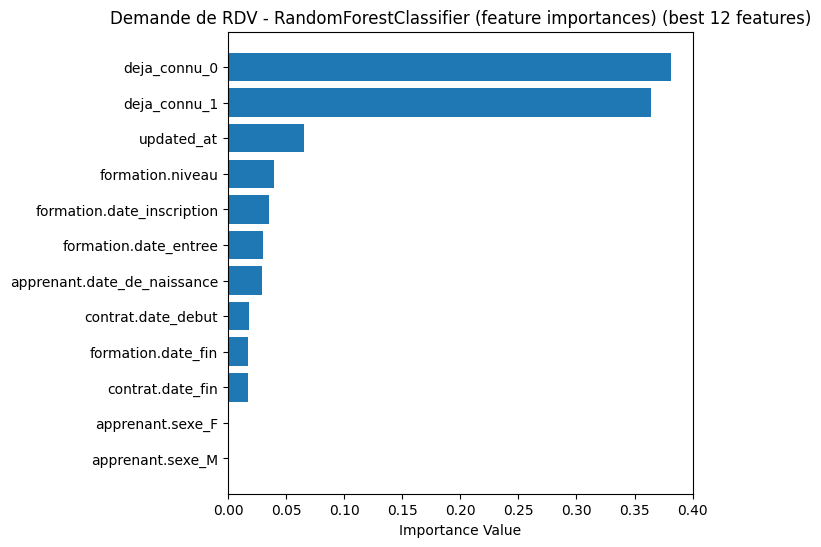

In [ ]:
feature_importance(pipeline)

## Bagging SGD (60%/80%)

BaggingClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.80      0.84      0.82      2899
         Oui       0.60      0.52      0.56      1310

    accuracy                           0.74      4209
   macro avg       0.70      0.68      0.69      4209
weighted avg       0.74      0.74      0.74      4209

BaggingClassifier CV: f1-score=0.7303 | std=0.0037


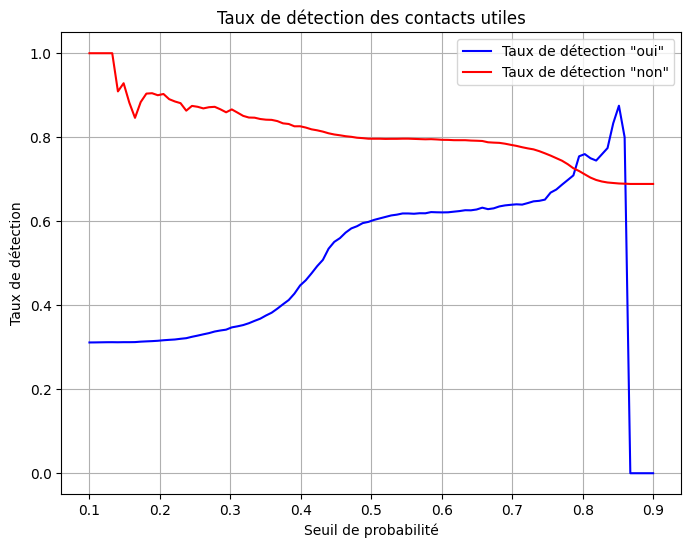

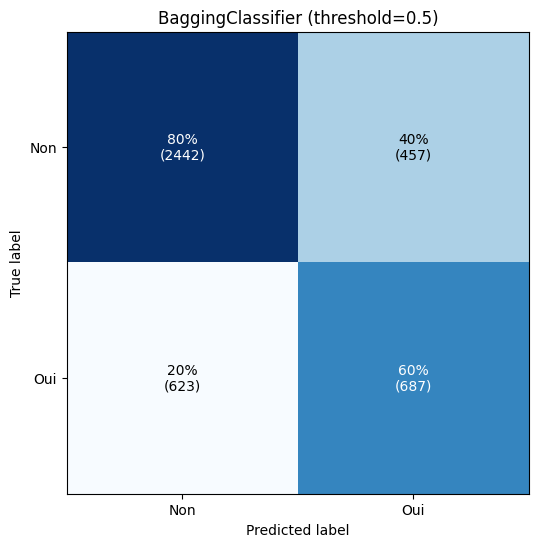

In [ ]:
# Bagging SGD
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import SGDClassifier

# Sparse-aware bagging
base_estimator = SGDClassifier(class_weight='balanced',
                               loss='log_loss',
                               random_state=42,
                               n_jobs=-1)
model = BaggingClassifier(
            estimator=base_estimator, # Changed base_estimator to estimator
            n_estimators=200,
            max_samples=0.2,  # Use 20% of samples per estimator
            n_jobs=-1,
            verbose=0
        )
pipeline = train_model(model, X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)
plot_confusion_matrix(X_test, y_test, pipeline)

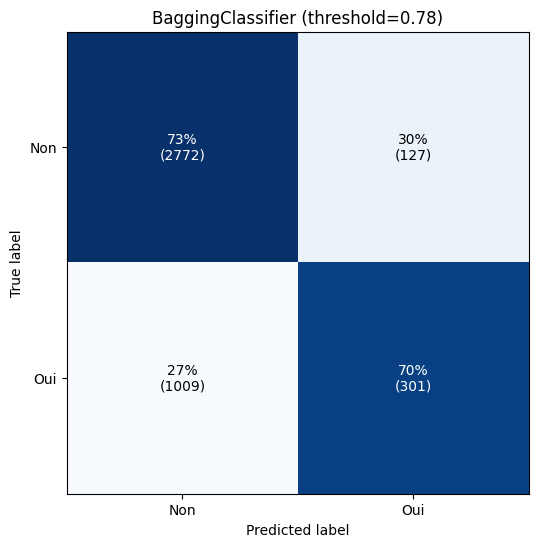

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.78)

# Upload model

In [ ]:
%%capture
!pip install huggingface_hub[hf_xet] # For fast model download

In [ ]:
# Save dataset to HF
import pandas as pd
from datasets import Dataset
repo_id = f"tableaudebord-apprentissage/contact-{EXPORT_DATE}"
hf_dataset = Dataset.from_pandas(dataset)

token = userdata.get('TBA_HF_TOKEN')
hf_dataset.push_to_hub(repo_id, private=True, token=token)
url = f"https://huggingface.co/datasets/{repo_id}"
print(url)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  323kB /  323kB            

https://huggingface.co/datasets/tableaudebord-apprentissage/contact-2026-04-20


In [ ]:
# Save model to HF
import joblib
from tempfile import mkdtemp, mkstemp
from pathlib import Path
from huggingface_hub import HfApi

classifier = pipeline
local_repo = mkdtemp(prefix="tmp-")
model_file = f"model.joblib"

joblib.dump(classifier, Path(local_repo) / model_file)
api = HfApi()

# Delete previous repo with the same name
try:
    print(f"Deleting existing repo: {repo_id}")
    api.delete_repo(repo_id=repo_id, token=token)
except:
    pass

# Create repo
print(f"Creating repo: {repo_id}")
api.create_repo(repo_id=repo_id, token=token, repo_type="model", private=True)

# Upload model
print(f"Uploading model: {local_repo}")
out = api.upload_folder(
    folder_path=local_repo,
    repo_id=repo_id,
    token=token,
    repo_type="model",
    commit_message=f"pushing model '{EXPORT_DATE}' model",
)
url = f"https://huggingface.co/{repo_id}"
print(url)

Deleting existing repo: tableaudebord-apprentissage/contact-2026-04-20
Creating repo: tableaudebord-apprentissage/contact-2026-04-20
Uploading model: /tmp/tmp-74cexvu6


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...tmp-74cexvu6/model.joblib: 100%|##########|  755kB /  755kB            

https://huggingface.co/tableaudebord-apprentissage/contact-2026-04-20


In [ ]:
# Download model
from huggingface_hub import hf_hub_download
import joblib
from google.colab import userdata
import os

repo_id = f"tableaudebord-apprentissage/contact-{EXPORT_DATE}"
model_file = "model.joblib"

print(f"Downloading model: {repo_id}")
model_dump = hf_hub_download(repo_id=repo_id, filename=model_file, token=token)

# Reload joblib model
# Add a check to ensure the file is not empty before loading
if os.path.getsize(model_dump) == 0:
    print(f"Error: The downloaded file {model_dump} is empty. Please try re-downloading the model or check the source.")
else:
    try:
        classifier = joblib.load(model_dump)
        print(f"Classifier model ready.")
    except EOFError:
        print(f"Error: The downloaded file {model_dump} is truncated or corrupted. Please try re-downloading the model.")
    except Exception as e:
        print(f"An unexpected error occurred while loading the model: {e}")

model.joblib:   0%|          | 0.00/755k [00:00<?, ?B/s]

Classifier model ready.


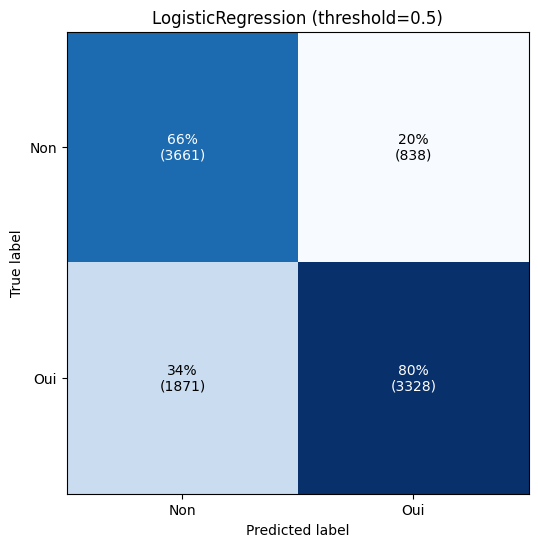

In [ ]:
# Test online model
plot_confusion_matrix(features, labels, classifier)

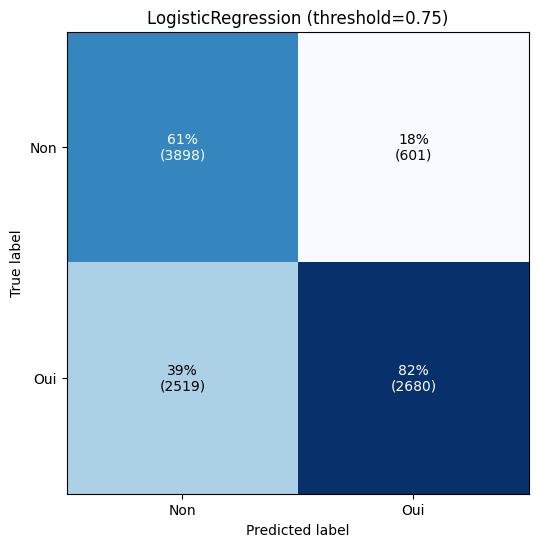

In [ ]:
# Test online model
plot_confusion_matrix(features, labels, classifier, 0.75)

# Model simulation
Apply variation on 'updated_at' field to search best score

In [ ]:
# Reload dataset
import pandas as pd
dataset = pd.read_csv(DATA_PATH + f'{EXPORT_DATE} ML accompagnement dataset.csv')
dataset.sample(3)

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture,updated_at,apprenant.sexe,mission_locale,deja_connu,formation.cfd,formation.rncp,formation.niveau,label
8468,-6566,-634,0,-634,-639,52,-224,-115,M,JEUNES DU VALENCIENNOIS,True,50023223,RNCP35889,3.0,Oui
2806,-7026,-300,0,-279,-298,736,-261,-194,M,INTERCOMMUNALE DE L'OUEST,True,40025214,RNCP40009,4.0,Oui
6696,-7321,-337,0,-337,-337,0,-306,-299,M,OCVA,True,56T31104,RNCP40216,3.0,Oui


In [ ]:
# Download model
from huggingface_hub import hf_hub_download
import joblib
from google.colab import userdata
import os

repo_id = f"tableaudebord-apprentissage/contact-{EXPORT_DATE}"
model_file = "model.joblib"

print(f"Downloading model: {repo_id}")
model_dump = hf_hub_download(repo_id=repo_id, filename=model_file, token=token)

# Reload joblib model
# Add a check to ensure the file is not empty before loading
if os.path.getsize(model_dump) == 0:
    print(f"Error: The downloaded file {model_dump} is empty. Please try re-downloading the model or check the source.")
else:
    try:
        classifier = joblib.load(model_dump)
        print(f"Classifier model ready.")
    except EOFError:
        print(f"Error: The downloaded file {model_dump} is truncated or corrupted. Please try re-downloading the model.")
    except Exception as e:
        print(f"An unexpected error occurred while loading the model: {e}")
classifier

Classifier model ready.


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['apprenant.date_de_naissance',
                                                   'formation.date_inscription',
                                                   'formation.date_fin',
                                                   'formation.date_entree',
                                                   'contrat.date_debut',
                                                   'contrat.date_fin',
                                                   'updated_at',
                                                   'formation.niveau']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['apprenant.sexe',
                                                   'deja_connu'])],
                                   verbose_feature_names_out=False)),
                ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
                ('model',
                 LogisticRegression(max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [ ]:
# Extract model features
feature_names_in = classifier.named_steps['preprocessor'].feature_names_in_
features = dataset[feature_names_in].copy()
labels = dataset['label'].copy()

# Compute score
y_probs = classifier.predict_proba(features)[:, 1]
features['score'] = y_probs
features['label'] = labels
features.sample(3)

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,updated_at,apprenant.sexe,deja_connu,formation.niveau,score,label
5939,-7550,-49,500,-49,-46,500,49,F,1,4.0,0.800584,Oui
7901,-8125,-158,203,-158,-158,215,32,M,0,6.0,0.231597,Non
3543,-8256,-217,245,-114,-508,250,25,M,0,7.0,0.263763,Non


In [ ]:
# Filter interested cases
filter = (features['label'] == 'Non') & (features['score'] < 0.5)
not_interested = features[filter]
interested = features[~filter]
print(f"- Not interested: {len(not_interested)}")
print(f"- Interested: {len(interested)}")

- Not interested: 3661
- Interested: 6037


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
import pandas as pd

def preprocess_sample(sample, preprocessor, numeric_features, categorical_features):
    """
    Preprocess a single sample using the pipeline's preprocessor.
    Returns the transformed sample as a numpy array.
    """
    # Convert sample to DataFrame for compatibility
    sample_df = pd.DataFrame([sample])

    # Apply the preprocessor
    sample_transformed = preprocessor.transform(sample_df)

    return sample_transformed[0]  # Return as 1D array

def optimize_feature_pipeline(
    pipeline, sample, feature_name, df, numeric_features, categorical_features,
    target_class=1, learning_rate=0.1, max_iter=1000, tol=1e-4
):
    """
    Optimize a feature value for a logistic regression model in a complex pipeline.
    """
    # Get the preprocessor and model from the pipeline
    preprocessor = pipeline.named_steps['preprocessor']
    model = pipeline.named_steps['model']

    # Preprocess the sample
    sample_transformed = preprocess_sample(sample, preprocessor, numeric_features, categorical_features)

    # Get the feature index in the transformed space
    # For numeric features: use the original index
    # For categorical features: use the one-hot encoded indices

    # This is a simplified example; you need to map feature_name to the correct index in the transformed space
    # For numeric features:
    if feature_name in numeric_features:
        feature_index = numeric_features.index(feature_name)
    # For categorical features: find the correct one-hot encoded index
    else:
        # This is more complex; see below for details
        pass

    # Get the coefficient and intercept from the logistic regression
    coef = model.coef_[0]
    intercept = model.intercept_[0]

    # Initialize the sample in the transformed space
    x_transformed = sample_transformed.copy()

    for _ in range(max_iter):
        # Compute current probability
        logit = np.dot(x_transformed, coef) + intercept
        prob = 1 / (1 + np.exp(-logit))
        if target_class == 0:
            prob = 1 - prob

        # Compute gradient
        gradient = prob * (1 - prob) * coef[feature_index]

        # Update feature value in transformed space
        new_x_transformed = x_transformed.copy()
        new_x_transformed[feature_index] += learning_rate * gradient

        # Compute new probability
        new_logit = np.dot(new_x_transformed, coef) + intercept
        new_prob = 1 / (1 + np.exp(-new_logit))
        if target_class == 0:
            new_prob = 1 - new_prob

        # Check for convergence
        if abs(new_prob - prob) < tol:
            break

        x_transformed = new_x_transformed

    # Inverse transform the optimized feature value
    optimized_value_original_scale = inverse_transform_feature(
        x_transformed, feature_name, feature_index, preprocessor, numeric_features, categorical_features, sample
    )

    return optimized_value_original_scale, new_prob

def inverse_transform_feature(
    x_transformed, feature_name, feature_index, preprocessor, numeric_features, categorical_features, original_sample
):
    """
    Inverse transform the optimized feature value back to the original scale.
    """
    # For numeric features: inverse scale
    if feature_name in numeric_features:
        scaler = preprocessor.named_transformers_['num'].named_steps['scaler']
        optimized_value_original_scale = x_transformed[feature_index] * scaler.scale_[feature_index] + scaler.mean_[feature_index]
    # For categorical features: inverse one-hot encoding (more complex)
    else:
        # This requires mapping the one-hot encoded indices back to the original categorical value
        # You may need to reconstruct the one-hot block and find the original category
        pass

    return optimized_value_original_scale

In [ ]:
results = not_interested.progress_apply(
    lambda row: optimize_feature_pipeline(
        classifier, row.to_dict(), 'updated_at', not_interested, numeric_features, categorical_features
    ),
    axis=1,
    result_type='expand'
)
not_interested[['best_updated_at', 'best_score']] = results

100%|██████████| 3661/3661 [00:20<00:00, 177.10it/s]
/tmp/ipykernel_11014/2322053524.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  not_interested[['best_updated_at', 'best_score']] = results


In [ ]:
not_interested

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,updated_at,apprenant.sexe,deja_connu,formation.niveau,score,label,best_updated_at,best_score
0,-5879,-104,563,-96,-162,567,285,F,0,3.0,0.306006,Non,285.000000,0.306087
4,-7860,-477,189,-477,-518,243,267,F,0,5.0,0.179470,Non,267.000000,0.179509
5,-5768,19,664,19,-37,692,384,M,0,3.0,0.276380,Non,384.000000,0.276452
7,-7547,-130,596,-130,-144,596,187,F,0,5.0,0.261910,Non,187.000000,0.261977
14,-9272,-88,275,-88,-88,275,109,F,0,7.0,0.192199,Non,109.000000,0.192242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9693,-7357,-162,147,-162,-78,207,75,F,0,5.0,0.260306,Non,75.000000,0.260372
9694,-7693,-162,201,-162,-44,201,66,F,0,6.0,0.221181,Non,66.000000,0.221234
9695,-6719,-130,161,-130,-53,199,65,F,0,4.0,0.301054,Non,65.000000,0.301133
9696,-5978,-201,449,-201,-211,510,13,F,0,3.0,0.416671,Non,-201.717521,0.526810


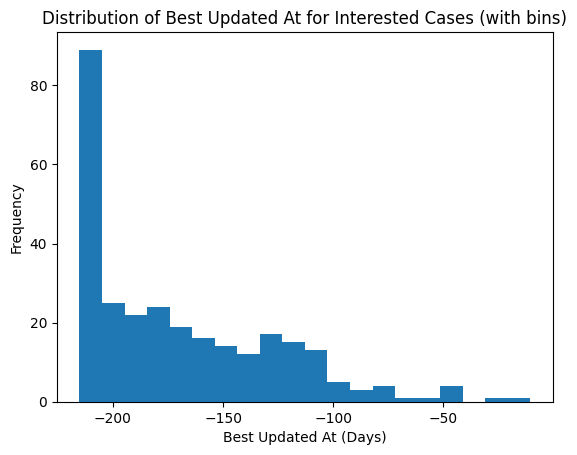

In [ ]:
filter = not_interested['best_score'] >= 0.5
plt.hist(not_interested[filter]['best_updated_at'], bins=20)
plt.xlabel('Best Updated At (Days)')
plt.ylabel('Frequency')
plt.title('Distribution of Best Updated At for Interested Cases (with bins)')
plt.show()


In [ ]:
interested['updated_at'].value_counts()

,count
updated_at,
0,489
95,58
92,54
62,52
34,52
...,...
214,1
262,1
275,1


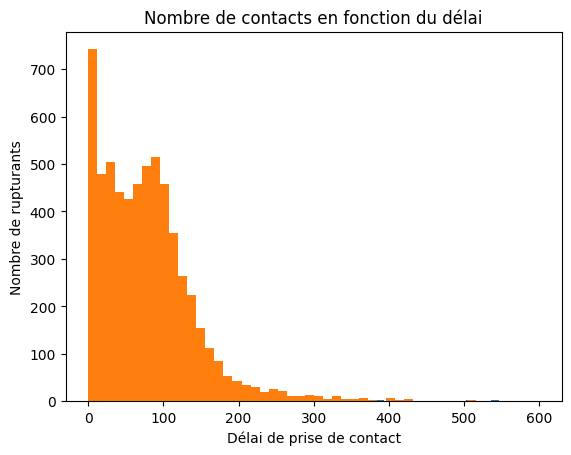

In [ ]:
plt.hist(not_interested['updated_at'], bins=50)
plt.hist(interested['updated_at'], bins=50)
plt.xlabel('Délai de prise de contact')
plt.ylabel('Nombre de rupturants')
plt.title('Nombre de contacts en fonction du délai')
plt.show()


In [ ]:
not_interested[filter]

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,updated_at,apprenant.sexe,deja_connu,formation.niveau,score,label,best_updated_at,best_score
28,-7335,-267,0,-193,-564,163,3,M,0,3.0,0.418197,Non,-211.793237,0.528413
89,-9281,-150,-54,-110,-119,610,94,F,0,3.0,0.471983,Non,-120.780038,0.582183
238,-5937,-185,558,-105,-109,620,119,F,0,3.0,0.402386,Non,-94.791841,0.511586
252,-5729,-77,182,-77,-153,599,142,F,0,3.0,0.449710,Non,-73.399890,0.560543
297,-7019,-75,-1,-35,-46,683,205,M,0,3.0,0.445412,Non,-10.421977,0.556268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9673,-5984,-158,481,-158,-228,501,39,F,0,3.0,0.407867,Non,-175.193712,0.517474
9683,-7109,-243,166,-190,-176,508,34,M,0,4.0,0.392756,Non,-178.941872,0.501097
9690,0,0,0,0,0,0,0,M,0,3.0,0.411736,Non,-214.442261,0.521596
9691,-5876,-150,475,-150,-169,530,32,M,0,3.0,0.399174,Non,-181.528900,0.508108


In [ ]:
print('Descriptive statistics for not_interested group:')
display(not_interested['updated_at'].describe())

print('\nDescriptive statistics for interested group:')
display(interested['updated_at'].describe())

Descriptive statistics for not_interested group:


,updated_at
count,3661.000000
mean,84.753073
std,64.981962
min,0.000000
25%,35.000000
50%,80.000000
75%,120.000000
max,547.000000



Descriptive statistics for interested group:


,updated_at
count,6037.000000
mean,77.864171
std,63.806378
min,0.000000
25%,30.000000
50%,71.000000
75%,108.000000
max,600.000000


In [ ]:
model = classifier['model']
coef = model.coef_[0]
intercept = model.intercept_[0]
coef, intercept

(array([ 0.1019718 , -0.09610141, -0.15328093,  0.23000978, -0.07946655,
         0.28880645, -0.13373087, -0.19357938,  0.09158237,  0.01894365,
        -0.95251615,  1.06304217]),
 np.float64(0.11052601829782799))

## Vizualise model tree

In [ ]:
print(f"Number of estimators: {len(rf_balanced_pipeline.named_steps['rf'].estimators_)}")

Number of estimators: 100


In [ ]:
from sklearn.tree import export_text

# Extraire le premier arbre de la forêt
tree = rf_balanced_pipeline.named_steps['rf'].estimators_[0]

# Afficher les règles sous forme de texte
tree_rules = export_text(tree, feature_names=feature_names_after_preprocessing)
print(tree_rules)

|--- contrat.date_debut <= 0.79
|   |--- contrat.date_debut <= -0.81
|   |   |--- formation.date_inscription <= -0.34
|   |   |   |--- contrat.date_rupture <= -0.38
|   |   |   |   |--- apprenant.date_de_naissance <= 1.85
|   |   |   |   |   |--- formation.date_fin <= -1.12
|   |   |   |   |   |   |--- formation.date_fin <= -1.15
|   |   |   |   |   |   |   |--- contrat.date_fin <= -1.21
|   |   |   |   |   |   |   |   |--- formation.date_inscription <= -0.37
|   |   |   |   |   |   |   |   |   |--- contrat.date_fin <= -1.33
|   |   |   |   |   |   |   |   |   |   |--- contrat.date_fin <= -1.44
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |   |   |   |   |   |   |--- contrat.date_fin >  -1.44
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |--- contrat.date_fin >  -1.33
|   |   |   |   |   |   |   |   |   |   |--- apprenant.date_de_naissance <= -0.76
|   |   |   |   |   |   

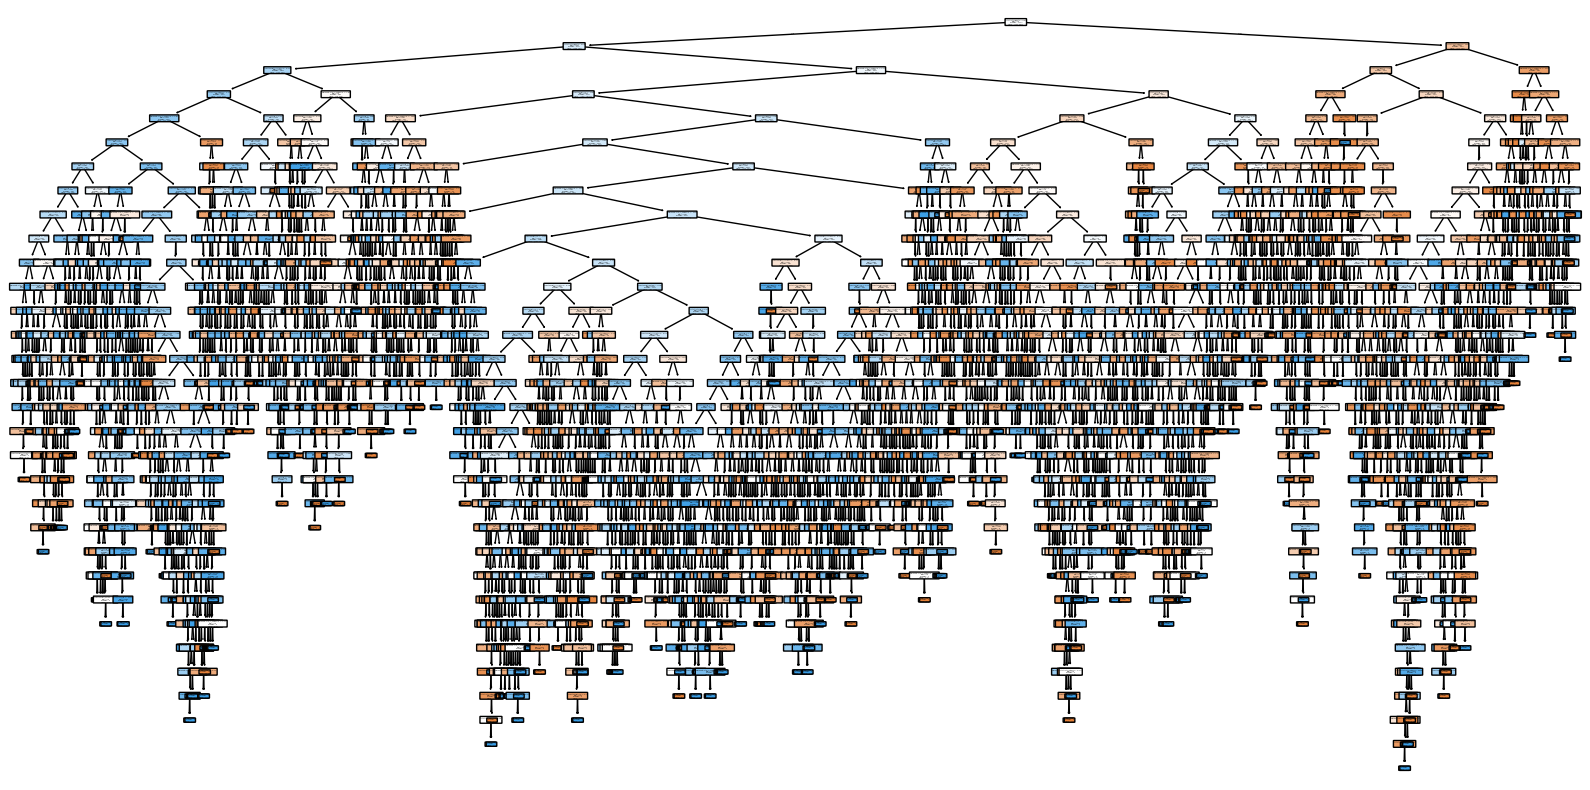

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=feature_names_after_preprocessing, filled=True, rounded=True)
plt.show()

# API

In [ ]:
data = effectifs[date_cols].sample(3)
data = data.to_dict(orient='records')
data

[{'apprenant.date_de_naissance': '2002-07-28T00:00:00.000Z',
  'formation.date_inscription': '2025-11-10T00:00:00.000Z',
  'formation.date_fin': '2027-05-09T00:00:00.000Z',
  'formation.date_entree': '2025-11-10T00:00:00.000Z',
  'contrat.date_debut': '2025-11-10T00:00:00.000Z',
  'contrat.date_fin': '2027-05-09T00:00:00.000Z',
  'contrat.date_rupture': '2025-12-15T00:00:00.000Z'},
 {'apprenant.date_de_naissance': '2001-04-07T00:00:00.000Z',
  'formation.date_inscription': '2024-12-05T00:00:00.000Z',
  'formation.date_fin': '2026-10-01T00:00:00.000Z',
  'formation.date_entree': '2024-12-05T00:00:00.000Z',
  'contrat.date_debut': '2024-12-02T00:00:00.000Z',
  'contrat.date_fin': '2026-10-01T00:00:00.000Z',
  'contrat.date_rupture': '2026-02-03T00:00:00.000Z'},
 {'apprenant.date_de_naissance': '2007-08-12T00:00:00.000Z',
  'formation.date_inscription': '2024-04-10T11:29:00.000Z',
  'formation.date_fin': '2025-06-30T00:00:00.000Z',
  'formation.date_entree': '2024-09-03T00:00:00.000Z',
  

In [ ]:
# Convert as json
import json
json_data = json.dumps(data)
json_data

'[{"apprenant.date_de_naissance": "2002-07-28T00:00:00.000Z", "formation.date_inscription": "2025-11-10T00:00:00.000Z", "formation.date_fin": "2027-05-09T00:00:00.000Z", "formation.date_entree": "2025-11-10T00:00:00.000Z", "contrat.date_debut": "2025-11-10T00:00:00.000Z", "contrat.date_fin": "2027-05-09T00:00:00.000Z", "contrat.date_rupture": "2025-12-15T00:00:00.000Z"}, {"apprenant.date_de_naissance": "2001-04-07T00:00:00.000Z", "formation.date_inscription": "2024-12-05T00:00:00.000Z", "formation.date_fin": "2026-10-01T00:00:00.000Z", "formation.date_entree": "2024-12-05T00:00:00.000Z", "contrat.date_debut": "2024-12-02T00:00:00.000Z", "contrat.date_fin": "2026-10-01T00:00:00.000Z", "contrat.date_rupture": "2026-02-03T00:00:00.000Z"}, {"apprenant.date_de_naissance": "2007-08-12T00:00:00.000Z", "formation.date_inscription": "2024-04-10T11:29:00.000Z", "formation.date_fin": "2025-06-30T00:00:00.000Z", "formation.date_entree": "2024-09-03T00:00:00.000Z", "contrat.date_debut": "2023-09-01

In [ ]:
json.loads(json_data)

[{'apprenant.date_de_naissance': '2002-07-28T00:00:00.000Z',
  'formation.date_inscription': '2025-11-10T00:00:00.000Z',
  'formation.date_fin': '2027-05-09T00:00:00.000Z',
  'formation.date_entree': '2025-11-10T00:00:00.000Z',
  'contrat.date_debut': '2025-11-10T00:00:00.000Z',
  'contrat.date_fin': '2027-05-09T00:00:00.000Z',
  'contrat.date_rupture': '2025-12-15T00:00:00.000Z'},
 {'apprenant.date_de_naissance': '2001-04-07T00:00:00.000Z',
  'formation.date_inscription': '2024-12-05T00:00:00.000Z',
  'formation.date_fin': '2026-10-01T00:00:00.000Z',
  'formation.date_entree': '2024-12-05T00:00:00.000Z',
  'contrat.date_debut': '2024-12-02T00:00:00.000Z',
  'contrat.date_fin': '2026-10-01T00:00:00.000Z',
  'contrat.date_rupture': '2026-02-03T00:00:00.000Z'},
 {'apprenant.date_de_naissance': '2007-08-12T00:00:00.000Z',
  'formation.date_inscription': '2024-04-10T11:29:00.000Z',
  'formation.date_fin': '2025-06-30T00:00:00.000Z',
  'formation.date_entree': '2024-09-03T00:00:00.000Z',
  

In [ ]:
# Reload as dataframe
import json
import pandas as pd
df = pd.DataFrame(json.loads(json_data))
df

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture
0,2002-07-28T00:00:00.000Z,2025-11-10T00:00:00.000Z,2027-05-09T00:00:00.000Z,2025-11-10T00:00:00.000Z,2025-11-10T00:00:00.000Z,2027-05-09T00:00:00.000Z,2025-12-15T00:00:00.000Z
1,2001-04-07T00:00:00.000Z,2024-12-05T00:00:00.000Z,2026-10-01T00:00:00.000Z,2024-12-05T00:00:00.000Z,2024-12-02T00:00:00.000Z,2026-10-01T00:00:00.000Z,2026-02-03T00:00:00.000Z
2,2007-08-12T00:00:00.000Z,2024-04-10T11:29:00.000Z,2025-06-30T00:00:00.000Z,2024-09-03T00:00:00.000Z,2023-09-01T00:00:00.000Z,2025-08-31T00:00:00.000Z,2024-12-31T00:00:00.000Z


In [ ]:
y_probs.tolist()

[0.05,
 0.07,
 0.1,
 0.01,
 0.14,
 0.06,
 0.06,
 0.08,
 0.07,
 0.11,
 0.74,
 0.0,
 0.2,
 0.87,
 0.04,
 0.16,
 0.04,
 0.04,
 0.08,
 0.03,
 0.04,
 0.04,
 0.07,
 0.77,
 0.03,
 0.11,
 0.05,
 0.04,
 0.01,
 0.13,
 0.03,
 0.12,
 0.02,
 0.89,
 0.8233333333333333,
 0.18,
 0.13,
 0.09,
 0.05,
 0.13,
 0.06,
 0.11,
 0.69,
 0.185,
 0.08,
 0.82,
 0.1,
 0.43333333333333335,
 0.15,
 0.0,
 0.1,
 0.02,
 0.07,
 0.05,
 0.0,
 0.0,
 0.04,
 0.02,
 0.0,
 0.0,
 0.0,
 0.16,
 0.0,
 0.125,
 0.09,
 0.18,
 0.06,
 0.13,
 0.76,
 0.08,
 0.12,
 0.01,
 0.06,
 0.02,
 0.1,
 0.26,
 0.08,
 0.0,
 0.08,
 0.01,
 0.06,
 0.1,
 0.25,
 0.04,
 0.25,
 0.16,
 0.1,
 0.18,
 0.74,
 0.01,
 0.01,
 0.09,
 0.12,
 0.02,
 0.03,
 0.11,
 0.06,
 0.12,
 0.75,
 0.2,
 0.10333333333333333,
 0.38,
 0.01,
 0.0,
 0.1,
 0.1,
 0.01,
 0.04,
 0.07,
 0.0,
 0.14,
 0.19333333333333336,
 0.69,
 0.1,
 0.06,
 0.04,
 0.03,
 0.03,
 0.03,
 0.11,
 0.18,
 0.12,
 0.14,
 0.01,
 0.07,
 0.06,
 0.18,
 0.01,
 0.16,
 0.05,
 0.12,
 0.21,
 0.06,
 0.03,
 0.11,
 0.82,
 0.23,
 0

# Inference

## Prepare dataset

In [ ]:
# ML effectifs
import pandas as pd
EXPORT_DATE = '2026-03-16'
ml_path = DATA_PATH + f'{EXPORT_DATE} ML EFFECTIFS TBA.csv'
ml_df = pd.read_csv(ml_path, low_memory=False)

organisations_tba = pd.read_parquet(DATA_PATH + f'{EXPORT_DATE} TBA ORGANISATIONS.parquet')
ml_tba = organisations_tba[organisations_tba['type']=='MISSION_LOCALE']

ml_df = ml_df.merge(ml_tba[['_id', 'nom']], left_on='mission_locale_id', right_on='_id')
print(f'- ml_df {EXPORT_DATE}: {ml_df.shape}')

- ml_df 2026-03-16: (138378, 211)


In [ ]:
# Filter situations
filter = ml_df['situation'].isna()
ml_unstarted = ml_df[filter].copy()
print(f'- ml_unstarted: {len(ml_unstarted)}')

- ml_unstarted: 123245


In [ ]:
# Prepare dataset
dataset = ml_unstarted.copy()
dataset['nom'].value_counts()

,count
nom,
DE PARIS,2783
DE MARSEILLE,2080
HAUTE-GARONNE,1860
"WE KER, Un territoire pour l'emploi",1562
NICE COTE D'AZUR,1552
...,...
MONTREUIL COTE D'OPALE,32
NEVERS SUD NIVERNAIS,19
94-ML BOISSY ST LEGER,17


In [ ]:
# Cast as dict
import ast
from tqdm import tqdm
tqdm.pandas()

# Casting effectifs
dataset['effectif_snapshot'] = dataset['effectif_snapshot'].progress_apply(ast.literal_eval)

100%|██████████| 123245/123245 [02:36<00:00, 785.93it/s] 


In [ ]:
# dataset.rename(columns={'nom':'mission_locale'}, inplace=True)
effectifs = dataset['effectif_snapshot'].progress_apply(pd.Series)

# Remove effectifs without contracts
#filter = effectifs['contrats'].apply(len) > 0
#effectifs = effectifs[filter]

apprenants = effectifs['apprenant'].progress_apply(pd.Series).add_prefix('apprenant.')
contrats = effectifs['contrats'].progress_apply(lambda x: pd.Series(x[0] if len(x)>0 else None)).add_prefix('contrat.')
formations = effectifs['formation'].progress_apply(pd.Series).add_prefix('formation.')
effectifs = pd.concat([apprenants, formations, contrats], axis=1)

date_cols = ['apprenant.date_de_naissance',
             'formation.date_inscription',
             'formation.date_fin',
             'formation.date_entree',
             'contrat.date_debut',
             'contrat.date_fin',
             'contrat.date_rupture',
]
features = effectifs[date_cols]

# Compute delay
today = pd.to_datetime('today', utc=True)
features = features.map(lambda x: today - pd.to_datetime(str(x), utc=True, errors='coerce'))
features = features.map(lambda x: x.days if isinstance(x, pd.Timedelta) else 0)
features.sample(3)

100%|██████████| 123245/123245 [00:31<00:00, 3873.83it/s]


,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture
16432,7560,564,-103,542,564,-164,0
75756,8735,199,-150,199,930,200,0
61468,8482,252,-168,206,206,-168,0


In [ ]:
# Build ml_features dataset
cols = ['nom', 'mission_locale_id', 'effectif_snapshot.apprenant.adresse.departement',
        'effectif_snapshot.apprenant.adresse.region']
ml_features = pd.concat([dataset[cols], features], axis=1).reset_index(drop=True)
ml_features

,nom,mission_locale_id,effectif_snapshot.apprenant.adresse.departement,effectif_snapshot.apprenant.adresse.region,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture
0,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",679623bce3a62593068efd20,47,75.0,8698,535,161,535,564,161,384
1,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",679623bce3a62593068efd20,47,75.0,7542,542,-103,542,595,-163,412
2,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",679623bce3a62593068efd20,47,75.0,7953,896,247,896,869,247,571
3,DU DELTA,67973e1be3a6259306900f65,13,93.0,6544,618,262,563,843,200,538
4,DU DELTA,67973e1be3a6259306900f65,13,93.0,6060,614,-110,570,577,-152,563
...,...,...,...,...,...,...,...,...,...,...,...
123240,DU PAYS DE BREST,67b756f84dc1b65fbd002fc6,29,53.0,8490,196,-483,196,199,-530,19
123241,DE LA BIEVRE,67b756f74dc1b65fbd002fb4,38,84.0,7152,210,-470,210,31,-530,0
123242,JEUNES GRAND AVIGNON,67b756f74dc1b65fbd002faa,84,93.0,8078,521,-109,521,595,-134,27
123243,D'INSERTION DU CENTRE HERAULT,67b756fa4dc1b65fbd003099,34,76.0,7186,549,-113,549,591,-165,20


In [ ]:
# Load regions
import warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
regions = pd.read_csv(DATA_PATH + 'REGIONS.csv', sep=';')
region_map = {}
for index, row in regions.iterrows():
    region_map[row['Nouveau Code']] = row['Nouveau Nom']
region_map[0] = ''
region_map[975] = 'Saint-Pierre-et-Miquelon'
region_map[977] = 'Saint-Barthélemy'
region_map[978] = 'Saint-Martin'
region_map[988] = 'Nouvelle-Calédonie'
print('- Regions loaded.')

# Load departements
departements = pd.read_csv(DATA_PATH + 'DEPARTEMENTS.csv', sep=',')

departement_map = {}
for index, row in departements.iterrows():
    departement_map[row['code_departement']] = row['nom_departement']
departement_map[''] = None
print("- Departements loaded")

- Regions loaded.
- Departements loaded


In [ ]:
# Add region / departement
ml_features['region'] = ml_features['effectif_snapshot.apprenant.adresse.region'].fillna(0).astype(int).map(region_map)
ml_features['departement'] = ml_features['effectif_snapshot.apprenant.adresse.departement'].fillna('').map(departement_map)
ml_features

,nom,mission_locale_id,effectif_snapshot.apprenant.adresse.departement,effectif_snapshot.apprenant.adresse.region,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture,region,departement
0,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",679623bce3a62593068efd20,47,75.0,8698,535,161,535,564,161,384,Nouvelle-Aquitaine,Lot-et-Garonne
1,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",679623bce3a62593068efd20,47,75.0,7542,542,-103,542,595,-163,412,Nouvelle-Aquitaine,Lot-et-Garonne
2,"DE L'AGENAIS, DE L'ALBRET ET DU CONFLUENT",679623bce3a62593068efd20,47,75.0,7953,896,247,896,869,247,571,Nouvelle-Aquitaine,Lot-et-Garonne
3,DU DELTA,67973e1be3a6259306900f65,13,93.0,6544,618,262,563,843,200,538,Provence-Alpes-Côte d'Azur,Bouches-du-Rhône
4,DU DELTA,67973e1be3a6259306900f65,13,93.0,6060,614,-110,570,577,-152,563,Provence-Alpes-Côte d'Azur,Bouches-du-Rhône
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123240,DU PAYS DE BREST,67b756f84dc1b65fbd002fc6,29,53.0,8490,196,-483,196,199,-530,19,Bretagne,Finistère
123241,DE LA BIEVRE,67b756f74dc1b65fbd002fb4,38,84.0,7152,210,-470,210,31,-530,0,Auvergne-Rhône-Alpes,Isère
123242,JEUNES GRAND AVIGNON,67b756f74dc1b65fbd002faa,84,93.0,8078,521,-109,521,595,-134,27,Provence-Alpes-Côte d'Azur,Vaucluse
123243,D'INSERTION DU CENTRE HERAULT,67b756fa4dc1b65fbd003099,34,76.0,7186,549,-113,549,591,-165,20,Occitanie,Hérault


In [ ]:
# Export features
ml_features.to_parquet(DATA_PATH + '2026-03-16 contacts effectifs ML.parquet', index=False)

## Run inference

In [ ]:
%%capture
!pip install huggingface_hub[hf_xet] # For fast model download

In [ ]:
# Reload model
# Download model
from huggingface_hub import hf_hub_download
import joblib
from google.colab import userdata
import os

EXPORT_DATE = '2026-03-16'
repo_id = f"tableaudebord-apprentissage/{EXPORT_DATE}"
model_file = f"tba-rf-ml-{EXPORT_DATE}.joblib"

print(f"Downloading model: {repo_id}")
token = userdata.get('TBA_HF_TOKEN')
model_dump = hf_hub_download(repo_id=repo_id, filename=model_file, token=token)

# Reload joblib model
# Add a check to ensure the file is not empty before loading
if os.path.getsize(model_dump) == 0:
    print(f"Error: The downloaded file {model_dump} is empty. Please try re-downloading the model or check the source.")
else:
    try:
        classifier = joblib.load(model_dump)
        print(f"Classifier model ready.")
    except EOFError:
        print(f"Error: The downloaded file {model_dump} is truncated or corrupted. Please try re-downloading the model.")
    except Exception as e:
        print(f"An unexpected error occurred while loading the model: {e}")

Classifier model ready.


In [ ]:
# Reload dataset
import pandas as pd
dataset = pd.read_parquet(DATA_PATH + '2026-03-16 contacts effectifs ML.parquet').reset_index(drop=True)
feat_cols = [col for col in dataset.columns if col.startswith('apprenant.') or col.startswith('formation.') or col.startswith('contrat.')]
ml_cols = [col for col in dataset.columns if col not in feat_cols]
features = dataset[feat_cols]
ml_list = dataset[ml_cols]
features.sample(3)

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture
16262,7630,610,-58,552,595,-164,520
87552,9345,178,-533,178,234,-533,123
32114,7805,577,262,570,1295,200,443


In [ ]:
ml_list.sample(3)

,nom,mission_locale_id,effectif_snapshot.apprenant.adresse.departement,effectif_snapshot.apprenant.adresse.region,region,departement
24076,SEMAPHORE - MULHOUSE SUD ALSACE,67b756fa4dc1b65fbd00307e,68,44.0,Grand Est,Haut-Rhin
10955,DE MONTARGIS - GIEN - AIJAM,67b756fa4dc1b65fbd00306f,45,24.0,Centre-Val de Loire,Loiret
36084,POUR LES JEUNES PAU - PYRENEES,67b756fa4dc1b65fbd003094,64,75.0,Nouvelle-Aquitaine,Pyrénées-Atlantiques


In [ ]:
# Score features
y_probs = classifier.predict_proba(features)[:, 1]
ml_scores = pd.concat([ml_list, pd.Series(y_probs, index=ml_list.index)], axis=1).rename(columns={0:'score'})
ml_cols = ['region', 'departement', 'nom', 'mission_locale_id', 'score']
ml_scores = ml_scores[ml_cols].sort_values(['region', 'departement', 'nom', 'score'], ascending=True).fillna('Inconnu').reset_index(drop=True)
ml_scores

,region,departement,nom,mission_locale_id,score
0,,Inconnu,AISPJ VAL D'OISE EST,67b756fb4dc1b65fbd0030d5,0.460000
1,,Inconnu,BORDEAUX AVENIR JEUNES,67b756f74dc1b65fbd002fbf,0.318333
2,,Inconnu,BRON DECINES MEYZIEU,67b756f84dc1b65fbd002ffa,0.560000
3,,Inconnu,D'INSERTION DU POITOU,67b756fa4dc1b65fbd00309d,0.500000
4,,Inconnu,DE L'ORLEANAIS,67b756fa4dc1b65fbd00308e,0.050000
...,...,...,...,...,...
123240,Saint-Martin,Inconnu,978-ML ST MARTIN,69860e0788a027c51e747b05,0.620000
123241,Saint-Martin,Inconnu,978-ML ST MARTIN,69860e0788a027c51e747b05,0.700000
123242,Saint-Martin,Inconnu,978-ML ST MARTIN,69860e0788a027c51e747b05,0.750000
123243,Saint-Martin,Inconnu,978-ML ST MARTIN,69860e0788a027c51e747b05,0.760000


In [ ]:
# Define the bins and labels
bins = [0, 0.25, 0.5, 0.75, 1]
labels = ['< 25%', '25-50%', '50-75%', '> 75%']

ml_bins = ml_scores.copy()

# Create a new column for the score bins
ml_bins['score_bin'] = pd.cut(ml_bins['score'], bins=bins, labels=labels, include_lowest=True)

# Count by mission_locale and score_bin
ml_bins = ml_bins.groupby(['nom', 'score_bin']).size().unstack(fill_value=0).reset_index()
ml_bins
# ml_bins.sort_values(['region', 'departement', 'nom', 'mission_locale_id'])

/tmp/ipykernel_3720/1828746177.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ml_bins = ml_bins.groupby(['nom', 'score_bin']).size().unstack(fill_value=0).reset_index()


score_bin,nom,< 25%,25-50%,50-75%,> 75%
0,POUR L'EMPLOI DES JEUNES D'ASNIERES ET DE VIL...,43,58,44,14
1,- Mission Intercommunale pour l'emploi des jeu...,87,197,121,31
2,50-ML GRANVILLE,3,13,25,2
3,58-ML NEVERS,2,20,23,5
4,73-ML BASSIN CHAMBERIEN,22,78,67,15
...,...,...,...,...,...
424,VALLEE SUD EMPLOI,148,156,115,15
425,VENDEE ATLANTIQUE,103,204,160,17
426,VERNON SEINE VEXIN,61,100,35,3
427,"VITA-LIS, MISSION LOCALE PARIS SACLAY",125,225,178,34


In [ ]:
ml_bins.to_csv(DATA_PATH + '2026-03-16 contacts opportuns effectifs ML.csv', index=False)

In [ ]:
# Reload dataset
import pandas as pd
ml_bins = pd.read_csv(DATA_PATH + '2026-03-16 contacts opportuns effectifs ML.csv')
ml_bins


,nom,< 25%,25-50%,50-75%,> 75%
0,POUR L'EMPLOI DES JEUNES D'ASNIERES ET DE VIL...,43,58,44,14
1,- Mission Intercommunale pour l'emploi des jeu...,87,197,121,31
2,50-ML GRANVILLE,3,13,25,2
3,58-ML NEVERS,2,20,23,5
4,73-ML BASSIN CHAMBERIEN,22,78,67,15
...,...,...,...,...,...
424,VALLEE SUD EMPLOI,148,156,115,15
425,VENDEE ATLANTIQUE,103,204,160,17
426,VERNON SEINE VEXIN,61,100,35,3
427,"VITA-LIS, MISSION LOCALE PARIS SACLAY",125,225,178,34
